# 🌊 Data drift — surveillance continue du modèle

Un modèle entraîné à un instant T peut **se dégrader** si la distribution
des données en production s'éloigne de celle d'entraînement. C'est le
**data drift** et il faut le détecter avant que les prédictions ne perdent
en qualité.

**Plan**

1. Pourquoi surveiller le drift
2. Indicateurs et tests statistiques
3. Setup
4. Construction d'un "current dataset" simulé
5. Rapport Evidently
6. Synthèse de la stratégie de réentraînement

## 1. Pourquoi surveiller le drift

| Cause typique | Effet sur le modèle |
|---------------|---------------------|
| Vieillissement de la clientèle | Distribution `AGE` décale → modèle moins précis sur les jeunes |
| Inflation / hausse de pouvoir d'achat | `LIMIT_BAL` augmente → ratios de risque biaisés |
| Crise économique → plus de retards | `PAY_*` se dégrade → seuil de décision plus pertinent |
| Changement de politique d'acquisition | Nouveaux profils non vus à l'entraînement |

Sans monitoring on découvre le problème **après** dégradation des résultats.
Avec monitoring on a un signal **avant** que la performance ne chute.

## 2. Indicateurs et tests statistiques

| Type de feature | Test utilisé | Idée |
|-----------------|--------------|------|
| Numérique | **Wasserstein distance** (normalisée) | Coût pour transformer une distribution en l'autre |
| Catégorielle | **Chi²** | Compare les fréquences observées |

**Seuils Evidently par défaut :**
- Numérique : drift si Wasserstein normalisé > 0.1
- Catégorielle : drift si p-value chi² < 0.05

**Dataset drift global** : "détecté" si plus de 50% des colonnes dérivent
(personnalisable).

## 3. ⚙️ Setup

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
FIG_DIR = ROOT / 'docs' / 'figures'

from scoring.drift import build_reference_and_current, run_drift_report, simulate_drifted_data
from scoring.data import PROCESSED_PATH, TARGET

## 4. Construction du dataset 'current' simulé

In [2]:
df = pd.read_parquet(PROCESSED_PATH)
print(f'Dataset total : {df.shape}')

# Le simulateur applique 3 changements réalistes :
# - AGE +3 ans (vieillissement clientèle)
# - LIMIT_BAL +20% (inflation)
# - PAY_0 plus de retards (crise économique)
reference, current = build_reference_and_current()
print(f'\nReference (train original) : {reference.shape}')
print(f'Current   (drifté)         : {current.shape}')

Dataset total : (30000, 36)

Reference (train original) : (24000, 36)
Current   (drifté)         : (6000, 36)


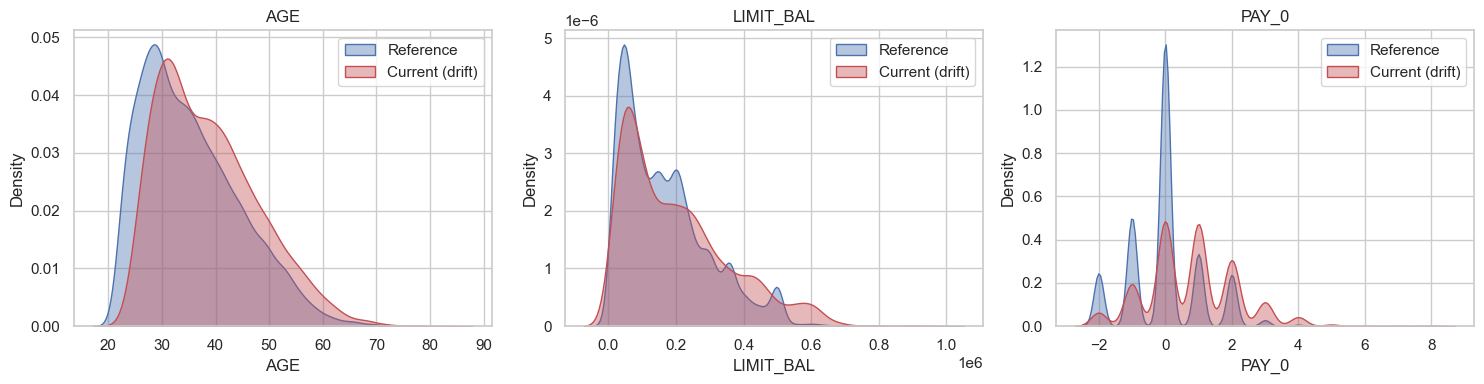

In [3]:
# Visualisation rapide : 3 features manipulées avant/après
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['AGE', 'LIMIT_BAL', 'PAY_0']):
    sns.kdeplot(reference[col], ax=ax, label='Reference', color='#4C72B0', fill=True, alpha=0.4)
    sns.kdeplot(current[col], ax=ax, label='Current (drift)', color='#C44E52', fill=True, alpha=0.4)
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / '30_drift_kde.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Rapport Evidently — détection des features dérivées

In [4]:
payload = run_drift_report(reference, current)

✓ HTML report saved to docs/drift_report.html
✓ JSON metrics saved to docs/drift_report.json


In [5]:
# Extraire les résultats par colonne
metrics = payload['metrics']
data_drift_table = next(m for m in metrics if m['metric'] == 'DataDriftTable')
columns = data_drift_table['result']['drift_by_columns']

drift_rows = []
for col_name, info in columns.items():
    drift_rows.append({
        'column': col_name,
        'type': info.get('column_type'),
        'stattest': info.get('stattest_name'),
        'drift_score': info.get('drift_score'),
        'threshold': info.get('stattest_threshold'),
        'drift_detected': info.get('drift_detected'),
    })

drift_df = pd.DataFrame(drift_rows).sort_values('drift_score', ascending=False)
drift_df.head(15).round(3)

,column,type,stattest,drift_score,threshold,drift_detected
16,PAY_0,num,Wasserstein distance (normed),0.709,0.1,True
0,AGE,num,Wasserstein distance (normed),0.355,0.1,True
10,LIMIT_BAL,num,Wasserstein distance (normed),0.266,0.1,True
23,PAY_AMT2,num,Wasserstein distance (normed),0.025,0.1,False
12,MAX_DELAY,num,Wasserstein distance (normed),0.024,0.1,False
25,PAY_AMT4,num,Wasserstein distance (normed),0.023,0.1,False
33,TOTAL_PAID,num,Wasserstein distance (normed),0.023,0.1,False
30,PAY_TREND,num,Wasserstein distance (normed),0.022,0.1,False
22,PAY_AMT1,num,Wasserstein distance (normed),0.022,0.1,False
24,PAY_AMT3,num,Wasserstein distance (normed),0.021,0.1,False


/var/folders/3y/1grlls_53njg5zgxj578h25h0000gn/T/ipykernel_67063/1433019917.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




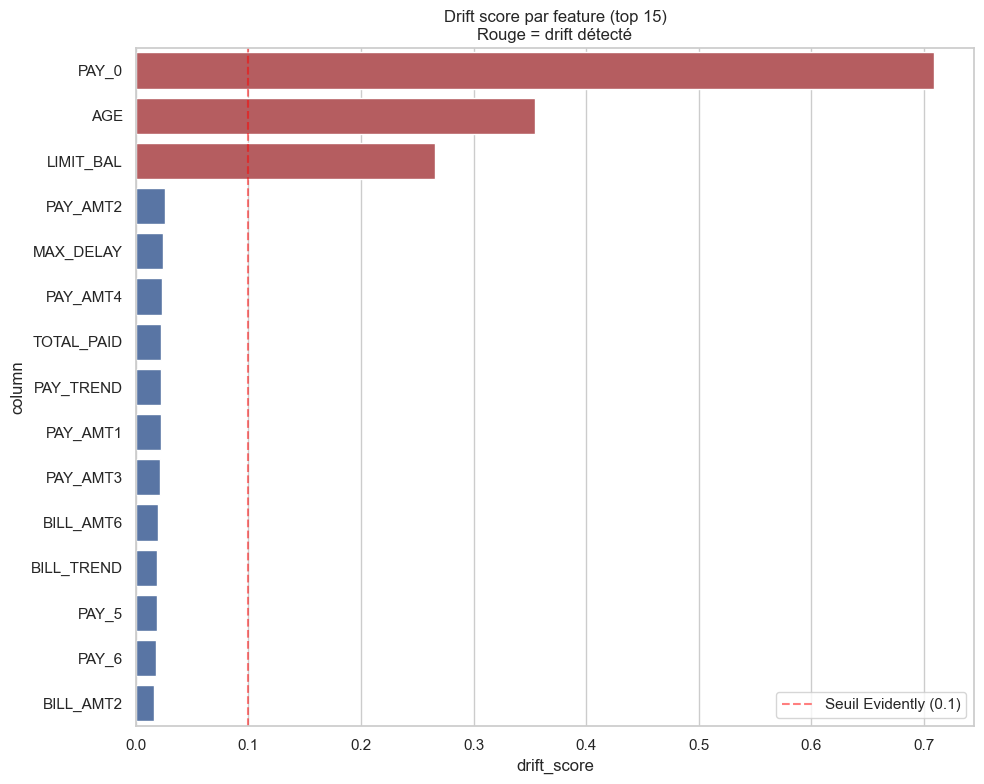

In [6]:
# Bar chart — top features par drift score
plt.figure(figsize=(10, 8))
top = drift_df.head(15)
colors = ['#C44E52' if d else '#4C72B0' for d in top['drift_detected']]
sns.barplot(x='drift_score', y='column', data=top, palette=colors)
plt.axvline(0.1, color='red', ls='--', alpha=0.5, label='Seuil Evidently (0.1)')
plt.title('Drift score par feature (top 15)\nRouge = drift détecté')
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / '30_drift_scores.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. 📌 Synthèse — stratégie de réentraînement

### Indicateurs à monitorer en prod

| Indicateur | Action |
|-----------|--------|
| `dataset_drift = True` | Réentraînement immédiat |
| `drift_share > 30%` | Alerte slack + investigation |
| Drift sur **PAY_0** | Réentraînement urgent (feature ultra-prédictive) |
| Variation du **business_gain** > -10% | Réentraînement immédiat |
| Variation **AUC** > -0.05 vs baseline | Alerte |

### Pipeline de réentraînement recommandé

```
Cron quotidien (ou trigger event-based) :
  1. Snapshot des prédictions des 30 derniers jours
  2. Comparer reference (train) vs current (last 30 days)
  3. Si dataset_drift = True :
       - Notifier Slack/Email
       - Lancer pipeline d'entraînement automatique (GitHub Action)
       - Comparer nouveau modèle vs production sur le business gain
       - Promouvoir si nouveau modèle > production + 2%
       - Rollback automatique si dégradation
```

### Artefacts produits ici

- `docs/drift_report.html` — rapport Evidently complet (interactif)
- `docs/drift_report.json` — métriques brutes pour le pipeline automatisé
- Figures `30_drift_kde.png` et `30_drift_scores.png` pour les slides